
Dataset: Iris Dataset
Accuracy: 0.9777777777777777

Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  1 12]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.93      1.00      0.96        13
           2       1.00      0.92      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



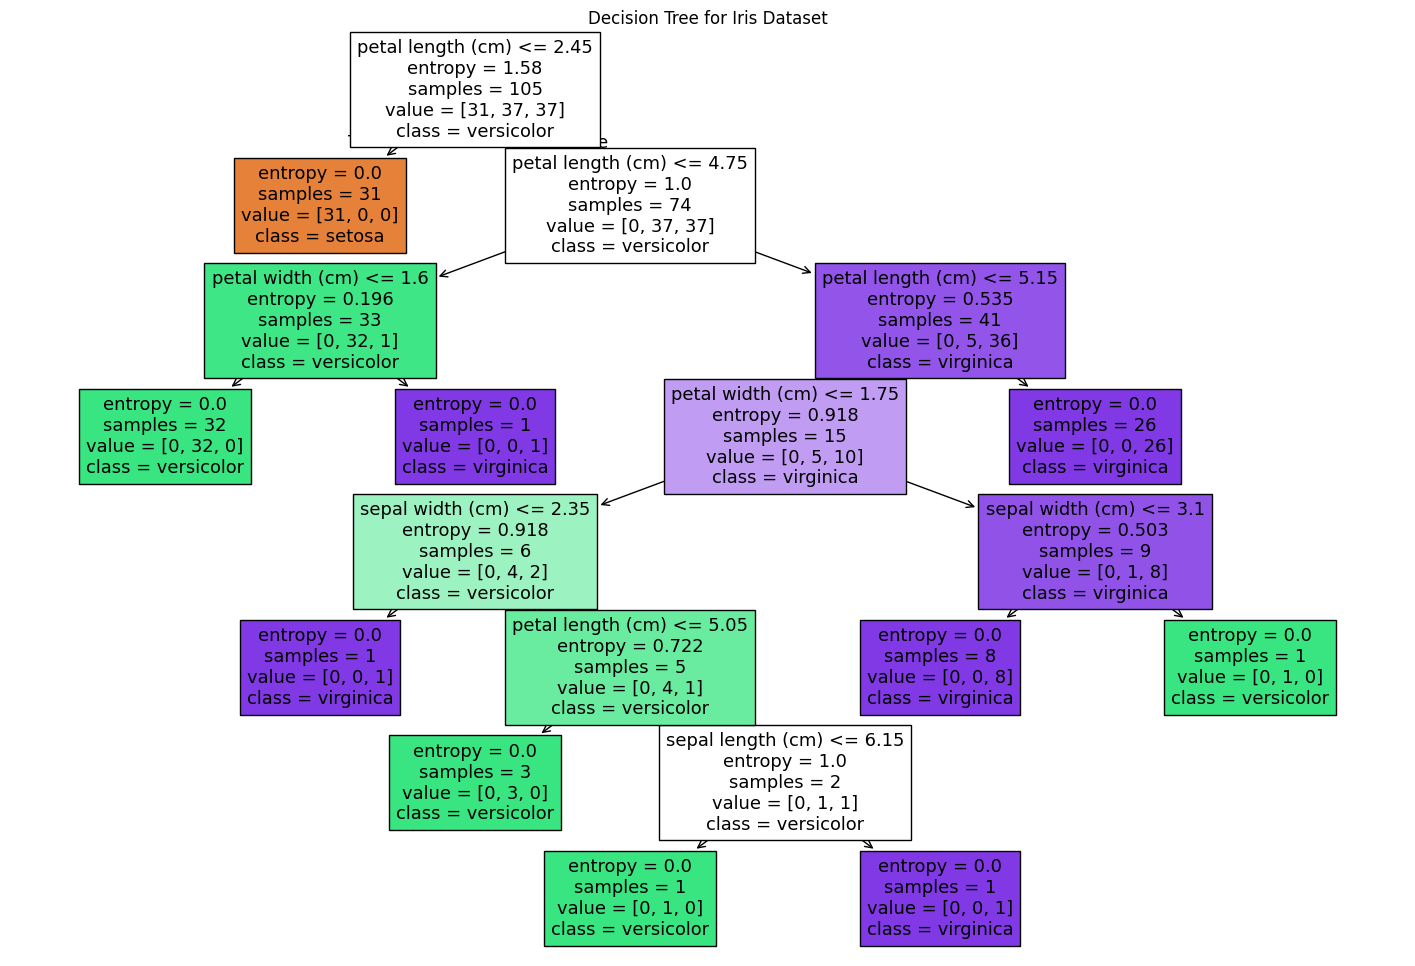

New Iris Sample Prediction: setosa

Dataset: Breast Cancer Dataset
Accuracy: 0.9649122807017544

Confusion Matrix:
 [[ 59   4]
 [  2 106]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.94      0.95        63
           1       0.96      0.98      0.97       108

    accuracy                           0.96       171
   macro avg       0.97      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



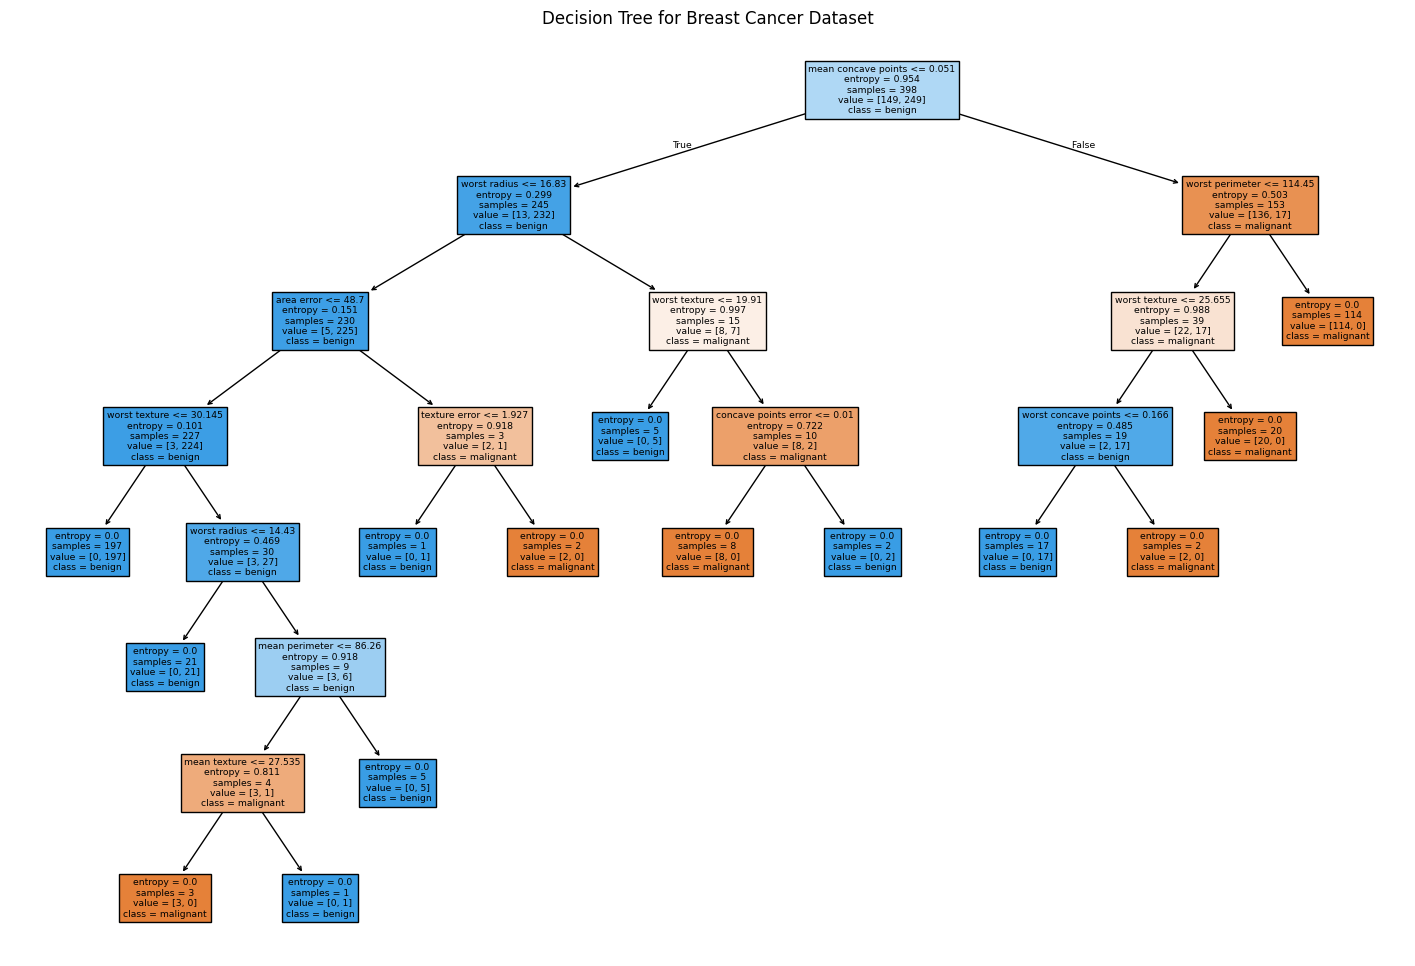

New Cancer Sample Prediction: malignant


In [3]:
# ============================================
# Decision Tree (ID3) on Two Different Datasets
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# --------------------------------------------
# Function to Train & Evaluate Model
# --------------------------------------------
def evaluate_model(dataset_loader, dataset_name):
    print(f"\n{'='*50}")
    print(f"Dataset: {dataset_name}")
    print(f"{'='*50}")

    # Load dataset
    data = dataset_loader()
    X = data.data
    y = data.target

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42)

    # ID3 uses Entropy
    model = DecisionTreeClassifier(criterion='entropy', random_state=42)
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # Plot tree (optional)
    plt.figure(figsize=(18,12))
    plot_tree(model, filled=True, feature_names=data.feature_names,
              class_names=data.target_names)
    plt.title(f"Decision Tree for {dataset_name}")
    plt.show()

    return model, data


# --------------------------------------------
# 1️⃣ IRIS DATASET
# --------------------------------------------
iris_model, iris_data = evaluate_model(load_iris, "Iris Dataset")

# Classifying new sample (Iris)
new_iris_sample = [[5.1, 3.5, 1.4, 0.2]]  # Example flower
prediction = iris_model.predict(new_iris_sample)
print("New Iris Sample Prediction:", iris_data.target_names[prediction][0])


# --------------------------------------------
# 2️⃣ BREAST CANCER DATASET
# --------------------------------------------
cancer_model, cancer_data = evaluate_model(load_breast_cancer, "Breast Cancer Dataset")

# Classifying new sample (Breast Cancer)
new_cancer_sample = [cancer_data.data[0]]  # Using first row as example
prediction = cancer_model.predict(new_cancer_sample)
print("New Cancer Sample Prediction:",
      cancer_data.target_names[prediction][0])